In [1]:
import numpy as np
import matplotlib.pyplot as plt

def plot_clusters(X, a):
    
    X = np.asarray(X)
    a = np.asarray(a)

    classes = np.unique(a)

    plt.figure()

    for k in classes:
        idx = a == k
        plt.scatter(X[idx, 0], X[idx, 1], label=f"class {k}")

    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.axis("equal")
    plt.show()

## K-Moyennes

Nous allons implémenter l'algorithme K-moyennes, l'utiliser sur un exemple simple (trois gaussiennes en 2D), puis montrer son utilisation comme algorithme de compression.

Vous n'avez rien à faire ici, on génère simplement notre dataset.

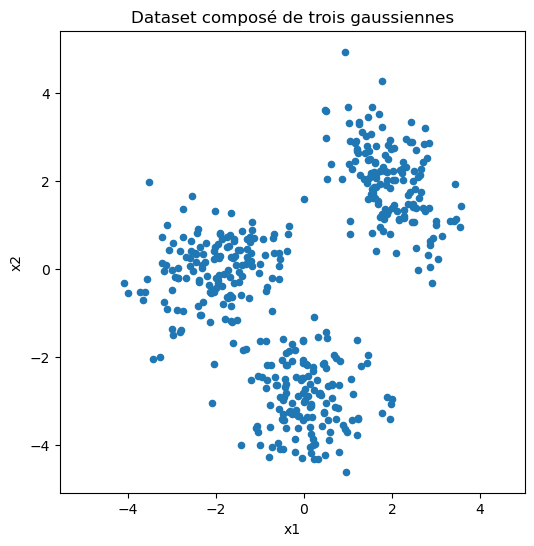

In [ ]:


np.random.seed(42)

# Nombre de points par cluser
n = 150

# Moyenne des trois gaussiennes
mu1 = [-2, 0]
mu2 = [2, 2]
mu3 = [0, -3]

# Matrices de covariance
cov1 = [[0.8, 0.2],
        [0.2, 0.5]]

cov2 = [[0.5, -0.3],
        [-0.3, 0.8]]

cov3 = [[0.6, 0],
        [0, 0.6]]


X1 = np.random.multivariate_normal(mu1, cov1, n)
X2 = np.random.multivariate_normal(mu2, cov2, n)
X3 = np.random.multivariate_normal(mu3, cov3, n)

X = np.vstack((X1, X2, X3))

# Plot
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=20)
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset composé de trois gaussiennes")
plt.axis("equal")
plt.show()

**Question 1.1**

Codez l'étape 1 de l'algorithme qui assigne aux points l'indice du centroïde le proche.


Par rapport au cours on change légèrement la notation pour l'affectation, nous avions dans le cours :

 $a_{n,k} = \begin{cases} 1 & \text{si } k = \argmin_i ||\vec{x}_n - \vec{\mu}_i||_2 \\ 0 & \text{sinon} \end{cases}$

 Nous allons ici considérer :

  $a_{n} = k =  \argmin_i ||\vec{x}_n - \vec{\mu}_i||_2 $

En d'autres la valeur de $a_{n}$ correspond simplement au cluster auquel appartient le point $\vec{x}_n$.

Les deux notations sont équivalentes, la seconde me semble plus naturelle informatiquement, mais vous pouvez penser l'inverse et conserver la première définition de $a$.


In [ ]:
def assigner_cluster(X,mu):
    '''
    Input :
    X : Données de dimension (N,D)
    mu : Centroïdes de dimension (K,D)
    Output :
    a : Vecteur d'assignation tel que pour tout k a[k] soit de l'élèment de mu le plus proche de X[k]
    '''
    N = X.shape[0]
    a = np.zeros(N,dtype=int)
    return a

**Question 1.2**

Codez l'étape 2 de l'algorithme qui calcule la position de chaque centroïde comme la moyenne des points qui lui ont été assignés.



In [ ]:
def update_centroides(X,a,K):
    '''
    Input :
    X : Données de dimension (N,D)
    a : Vecteur d'assignation de dimension (N)
    Output :
    mu : Centroïdes de dimension (K,D), tel que mu[k] soit la moyenne des X[n] tels que a[n]=k
    '''
    D = X.shape[1]
    mu = np.zeros((K,D))

    return mu

**Question 1.3**

Codez l'algorithme complet des K-moyennes


In [ ]:
def K_moyennes(X,K):
    '''
    Input :
    X : Données de dimension (N,D)
    Output :
    mu : Centroïdes de dimension (K,D)
    a : Vecteur d'assignation de dimension (N)
    '''
    mu = X[np.random.choice(X.shape[0], K, replace=False)] # On vous donne l'initialisation de mu, on prend simplement K points aléatoirement dans X
    
    return (mu,a)

**Question 1.4**
Essayez votre algorithme avec différentes valeurs de K, observez le résultat.

In [ ]:
K = 2
mu, a = K_moyennes(X,K)
plot_clusters(X,a)

**Question 1.4**
Ecrivez la loss function, on rappelle sa formule :

$ J =  \sum_n^N \sum_k^K a_{n,k}||\vec{x}_n-\vec{\mu}_k||_2^2 $

Vous avez déjà tous les élèments grâce aux fonctions précédentes .


In [ ]:
def loss(X,mu,a):
    '''
    Input :
    X : Données de dimension (N,D)
    mu : Centroïdes de dimension (K,D)
    a : Vecteur d'assignation de dimension (N)
    Output :
    L : Loss
    '''
    L = 0
    return L

**Question 1.5** On plot la loss en fonction du choix de K.

Pouvez vous observer une inflection dans la courbe pour un certain K ? Est ce cohérent ?

Parfois cette zone se nomme le "coude" de la courbe et c'est un bon indice du K à choisir.

In [ ]:
lloss = []
for K in range(1,10):
    mu, a = K_moyennes(X,K)
    lloss.append(loss(X,mu,a))
plt.plot(range(1,10),lloss)

### Appliation des K-moyennes aux images

Une image est composée de millions de pixels, chacun défini par une couleur, un pixel est donc un point dans un espace à 3 dimensions (Rouge, Vert, Bleu). L'idée est d'observer que ces millions de couleurs ne sont pas réparties uniformément : elles forment des groupes naturels dans cet espace. Une photo de forêt aura un grand cluster de verts, une photo de ciel un grand cluster de bleus.

On applique K-moyennes sur ces pixels : on trouve K centroïdes, et on remplace la couleur de chaque pixel par la couleur du centroïde le plus proche. Au lieu de stocker des millions de couleurs distinctes, on n'en stocke que K, d'où la compression.

Plus K est petit, plus l'image est compressée, mais plus elle perd en qualité.

On vous donne ci dessous le code pour charger une image. 

Suivant l'implémentation de votre algorithme, le temps de calcul peut être long, on vous donne donc quatre versions de la même image dans des tailles différentes big, mid, small et micro. La taille big demande un code vraiment bien optimisé (full numpy), mid&small devrait tourner avec un code utilisant un peu de numpy, micro pour un code python plus classique avez quelques lenteurs. 

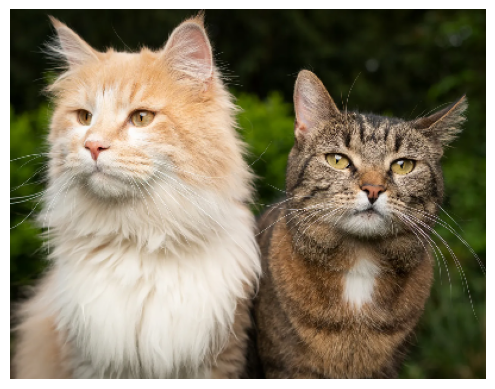

In [12]:
from PIL import Image

img = Image.open("mid_cats.png").convert("RGB")
arr = np.array(img)
plt.imshow(arr)
plt.axis('off')
plt.show()

**Question 2.1**

Appliquez K-moyennes à l'image

In [11]:
X = arr.reshape(-1,3)
K = 3
mu, a = #TODO

SyntaxError: invalid syntax (1268296351.py, line 3)

**Question 2.2** transformez l'image en X_transforme tel quel si X[n] soit de classe $k$ alors X_transforme[n] contienne le centroide $\mu_k$

In [ ]:
def transforme(X,mu,a):
    '''
    Input :
    X : Données de dimension (N,D)
    mu : Centroïdes de dimension (K,D)
    a : Vecteur d'assignation de dimension (N)
    Output :
    X_transforme tel que X_transforme[n] contienne le centroide mu[k] avec k la classe de X[n]
    '''
    X_transforme = np.zeros_like(X)
    #TODO
    return X_transforme

Observez l'image après transformation, modifiez la valeur de K.

In [ ]:
X = arr.reshape(-1,3)
K = 3
mu, a = K_moyennes(X,K)
X_transforme = transforme(X,mu,a)
H, W = img.size[1], img.size[0]
arr_new = X_transforme.reshape(H, W, 3)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(arr)
plt.axis('off')
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(arr_new)
plt.axis('off')
plt.title(f"Compressée avec K={K}")

plt.show()

## Arbres de décision (bonus)

Nous allons utiliser sklearn pour les arbres de décision.

On souhaite mesurer les performances, nottament en fonction de la profondeur de l'arbre.

Nous allons pour cela prendre (presque) le même dataset que pour k-moyennes, mais en considérant les classes connues (et l'on souhaite apprendre un modèle classifiant de nouveaux points).

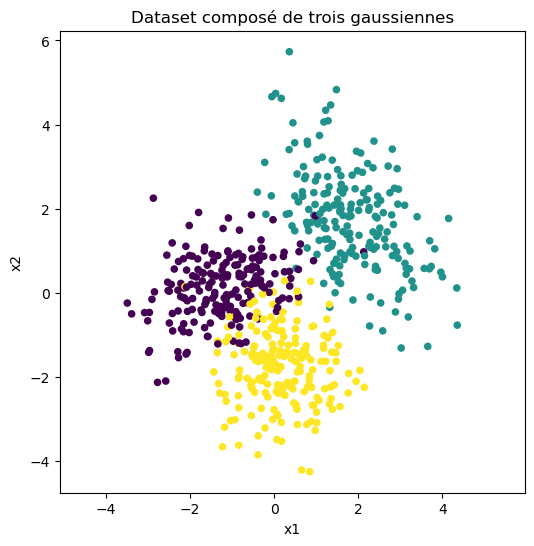

In [24]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(42)

# Nombre de points par cluser
n = 200

# Moyenne des trois gaussiennes
mu1 = [-1.2, 0.1]
mu2 = [1.8, 1.8]
mu3 = [0, -1.8]

# Matrices de covariance
cov1 = np.array([[0.8, 0.2],[0.2, 0.5]]) *1.2

cov2 =  np.array([[0.5, -0.3],[-0.3, 0.8]])*1.8

cov3 =  np.array([[0.6, 0],[0, 0.6]])*1.2


X1 = np.random.multivariate_normal(mu1, cov1, n)
Y1 = np.full(n, 0)
X2 = np.random.multivariate_normal(mu2, cov2, n)
Y2 = np.full(n, 1)
X3 = np.random.multivariate_normal(mu3, cov3, n)
Y3 = np.full(n, 2)

X = np.vstack((X1, X2, X3))
Y = np.concat((Y1, Y2, Y3))
shuffled_indices = np.random.permutation(3*n)
X = X[shuffled_indices]
Y = Y[shuffled_indices]


# Plot
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=20, c=Y, cmap='viridis')
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Dataset composé de trois gaussiennes")
plt.axis("equal")
plt.show()

**Question 3.1** Découpez le data set en train-test (75\%-25\%)

In [25]:
X_train =
y_train =
X_test =
y_test = 

SyntaxError: invalid syntax (1398079674.py, line 1)

**Question 3.2** Allez voir la doc de DecisionTreeClassifier de sklearn

Entrainez un arbre de décision sur votre data set, réglez la profondeur `max_depth` de l'arbre à 4.

Calculez le score sur train et test.

In [26]:
from sklearn.tree import DecisionTreeClassifier


**Question 3.3** 

Entrainez un arbre de décision pour différentes valeurs `max_depth`, affichez le train et test score.

In [27]:
depth_range =  range(1,10)
lscore_train = []
lscore_test = []
#TODO


In [ ]:
plt.plot(depth_range,lscore_test,label="Train score")
plt.plot(depth_range,lscore_test,label="Test score")

**Question 3.4** 

Quelle profondeur vous semble la meilleure ? Justifiez.